In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_cleaned.csv")

df["invoicedate"] = pd.to_datetime(df["invoicedate"])

df.head()

C:\Users\ashra\AppData\Local\Temp\ipykernel_2040\2029681780.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/online_retail_cleaned.csv")


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,year,month,month_year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,2009-12


In [2]:
monthly_revenue = (
    df.groupby("month_year")["revenue"]
    .sum()
    .reset_index()
    .sort_values("month_year")
)

monthly_revenue.head()

,month_year,revenue
0,2009-12,822483.950
1,2010-01,651155.112
2,2010-02,551504.726
3,2010-03,830915.261
4,2010-04,678875.252


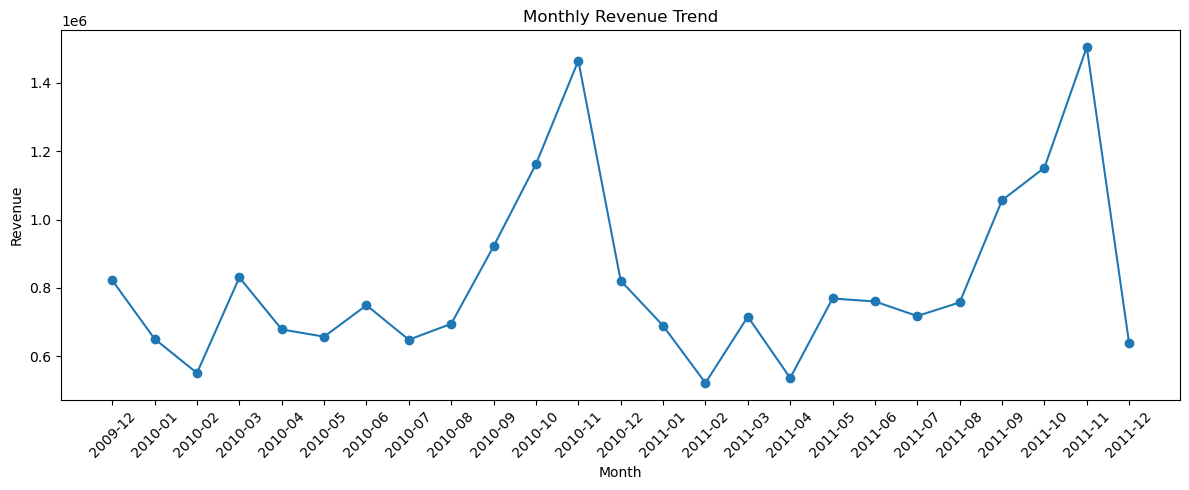

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month_year"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Monthly Revenue Trend Insight

Revenue increases strongly during September, October, and November, with November being the highest revenue month in both 2010 and 2011. This suggests seasonal demand before the holiday period.

The drop in December 2011 should not be treated as a business decline because the dataset only contains data until December 9, 2011.

Business action: The company should prepare inventory, marketing campaigns, and logistics before September to capture peak seasonal demand.

In [4]:
country_revenue = (
    df.groupby("country")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

country_revenue.head(10)

,country,revenue
40,United Kingdom,1.741020e+07
11,EIRE,6.587673e+05
26,Netherlands,5.540381e+05
15,Germany,4.250197e+05
14,France,3.504561e+05
0,Australia,1.692835e+05
34,Spain,1.083325e+05
36,Switzerland,1.006856e+05
35,Sweden,9.186982e+04
10,Denmark,6.858069e+04


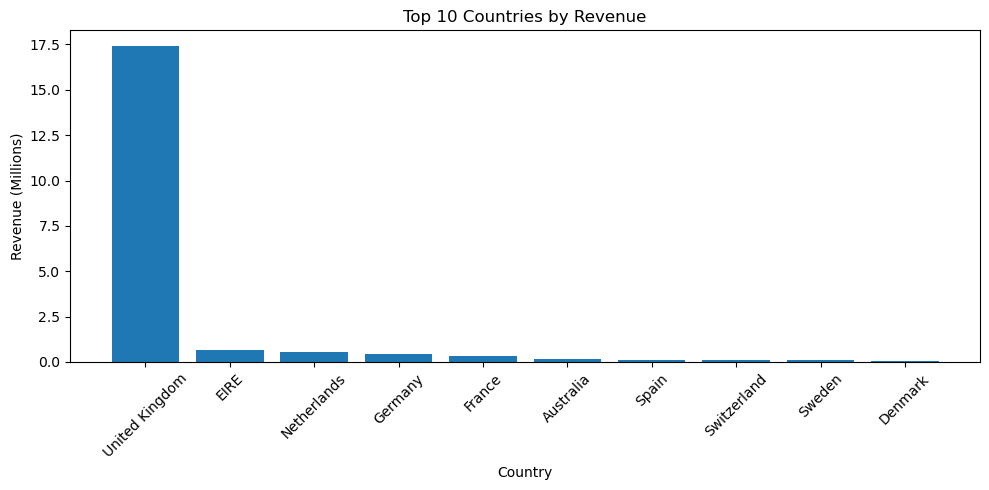

In [6]:
top_10_countries = country_revenue.head(10).copy()

top_10_countries["revenue_million"] = top_10_countries["revenue"] / 1_000_000

plt.figure(figsize=(10, 5))
plt.bar(top_10_countries["country"], top_10_countries["revenue_million"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (Millions)")
plt.tight_layout()
plt.show()

### Country Revenue Insight

The United Kingdom generates the majority of total revenue, far ahead of all other countries. EIRE, Netherlands, Germany, and France are the strongest international markets, but their revenue is much smaller compared to the UK.

Business action: The company should protect its UK customer base while also exploring growth opportunities in strong international markets such as EIRE, Netherlands, Germany, and France.

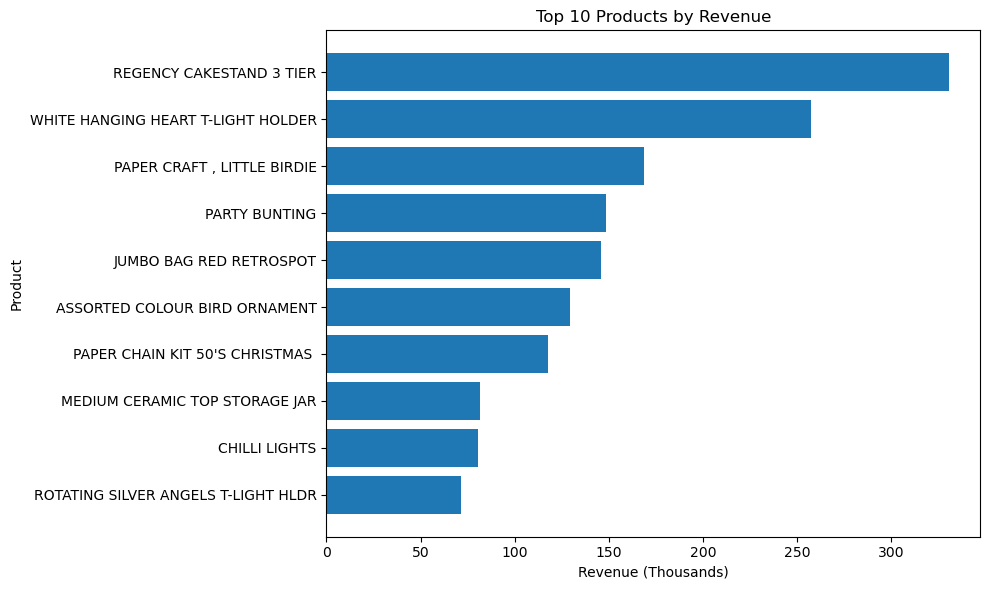

In [11]:
top_10_products = product_revenue.head(10).copy()
top_10_products["revenue_thousand"] = top_10_products["revenue"] / 1000

plt.figure(figsize=(10, 6))
plt.barh(top_10_products["description"], top_10_products["revenue_thousand"])
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (Thousands)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [30]:
non_product_codes = ["M", "DOT", "POST"]

real_products = df[~df["stockcode"].isin(non_product_codes)]

product_revenue = (
    real_products
    .groupby(["stockcode", "description"])["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

product_revenue.head(10)

,stockcode,description,revenue
1891,22423,REGENCY CAKESTAND 3 TIER,330590.32
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3716,47566,PARTY BUNTING,148318.28
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29
2810,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
4058,79321,CHILLI LIGHTS,80540.88
4227,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,71300.40


### Top Products by Revenue Insight

After removing non-product codes such as Manual, DOTCOM POSTAGE, and POSTAGE, the top revenue-generating real products are REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER.

Business action: The company should ensure these products remain well-stocked, especially before peak sales months, and consider using them in promotions or product bundles.

In [12]:
customer_revenue = (
    df.dropna(subset=["customer_id"])
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

customer_revenue.head(10)

,customer_id,revenue
5692,18102.0,580987.04
2277,14646.0,528602.52
1789,14156.0,313437.62
2538,14911.0,291420.81
5050,17450.0,244784.25
1331,13694.0,195640.69
5109,17511.0,172132.87
4061,16446.0,168472.50
4295,16684.0,147142.77
68,12415.0,144458.37


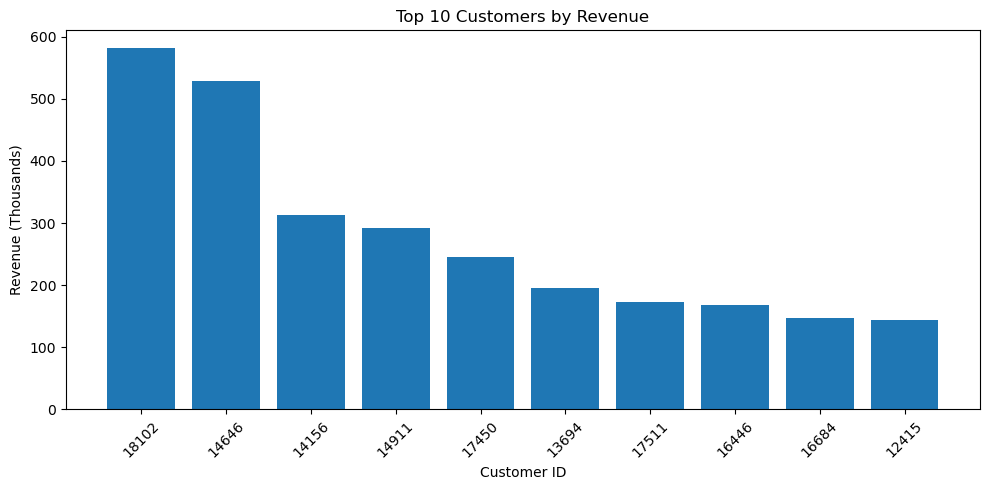

In [13]:
top_10_customers = customer_revenue.head(10).copy()
top_10_customers["customer_id"] = top_10_customers["customer_id"].astype(int).astype(str)
top_10_customers["revenue_thousand"] = top_10_customers["revenue"] / 1000

plt.figure(figsize=(10, 5))
plt.bar(top_10_customers["customer_id"], top_10_customers["revenue_thousand"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (Thousands)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top Customers by Revenue Insight

The chart shows that a small group of customers generate a large amount of revenue. Customer 18102 and Customer 14646 are the highest-value customers, each contributing more than 500K in revenue.

This indicates that the business has a group of VIP customers who are very important to overall sales performance.

Business action: The company should create retention strategies for these high-value customers, such as loyalty rewards, personalized offers, early product access, or dedicated customer support.

In [14]:
top_customer_ids = customer_revenue.head(10)["customer_id"]

top_customer_country = (
    df[df["customer_id"].isin(top_customer_ids)]
    .groupby(["customer_id", "country"])["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

top_customer_country

,customer_id,country,revenue
9,18102.0,United Kingdom,580987.04
3,14646.0,Netherlands,528602.52
2,14156.0,EIRE,313437.62
4,14911.0,EIRE,291420.81
7,17450.0,United Kingdom,244784.25
1,13694.0,United Kingdom,195640.69
8,17511.0,United Kingdom,172132.87
5,16446.0,United Kingdom,168472.50
6,16684.0,United Kingdom,147142.77
0,12415.0,Australia,144458.37


In [31]:
top_customer_products_overall = (
    df[df["customer_id"].isin(top_customer_ids)]
    .groupby(["stockcode", "description"])["revenue"]
    .sum()
    .reset_index()
    .rename(columns={"revenue": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
)

In [32]:
non_product_descriptions = ["Manual"]

top_customer_products_overall_clean = (
    top_customer_products_overall[
        ~top_customer_products_overall["description"].isin(non_product_descriptions)
    ]
)

top_customer_products_overall_clean.head(10)

,stockcode,description,total_revenue
2621,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3426,85123A,WHITE HANGING HEART T-LIGHT HOLDER,38128.16
1459,22423,REGENCY CAKESTAND 3 TIER,32275.65
766,21623,VINTAGE UNION JACK MEMOBOARD,26850.88
2967,82484,WOOD BLACK BOARD ANT WHITE FINISH,26221.45
1215,22189,CREAM HEART CARD HOLDER,23548.58
1214,22188,BLACK HEART CARD HOLDER,19655.84
1510,22470,HEART OF WICKER LARGE,16734.94
3412,85099B,JUMBO BAG RED RETROSPOT,16054.60
1668,22629,SPACEBOY LUNCH BOX,15249.60


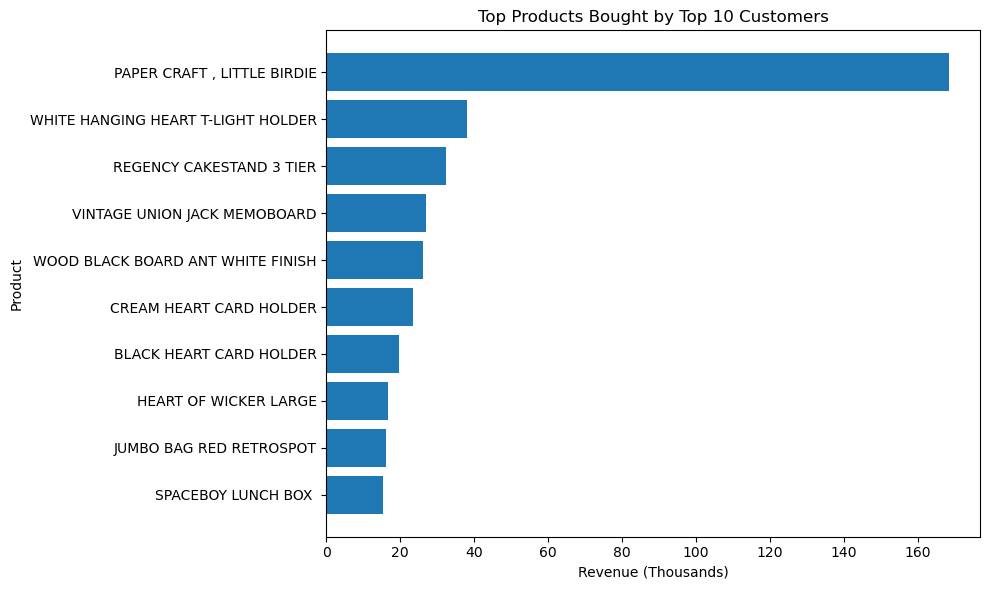

In [19]:
top_10_vip_products = top_customer_products_overall_clean.head(10).copy()
top_10_vip_products["revenue_thousand"] = top_10_vip_products["total_revenue"] / 1000

plt.figure(figsize=(10, 6))
plt.barh(top_10_vip_products["description"], top_10_vip_products["revenue_thousand"])
plt.gca().invert_yaxis()
plt.title("Top Products Bought by Top 10 Customers")
plt.xlabel("Revenue (Thousands)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Products Bought by Top Customers Insight

Among the top 10 customers, PAPER CRAFT, LITTLE BIRDIE generates the highest revenue, followed by WHITE HANGING HEART T-LIGHT HOLDER and REGENCY CAKESTAND 3 TIER.

This shows that VIP customers are strongly contributing to revenue from a few key products.

Business action: The company should use these products in VIP-focused promotions, bundles, and personalized recommendations.

In [20]:
monthly_orders = (
    df.groupby("month_year")["invoice"]
    .nunique()
    .reset_index()
    .sort_values("month_year")
)

monthly_orders.rename(columns={"invoice": "total_orders"}, inplace=True)

monthly_orders.head()

,month_year,total_orders
0,2009-12,1682
1,2010-01,1105
2,2010-02,1201
3,2010-03,1681
4,2010-04,1462


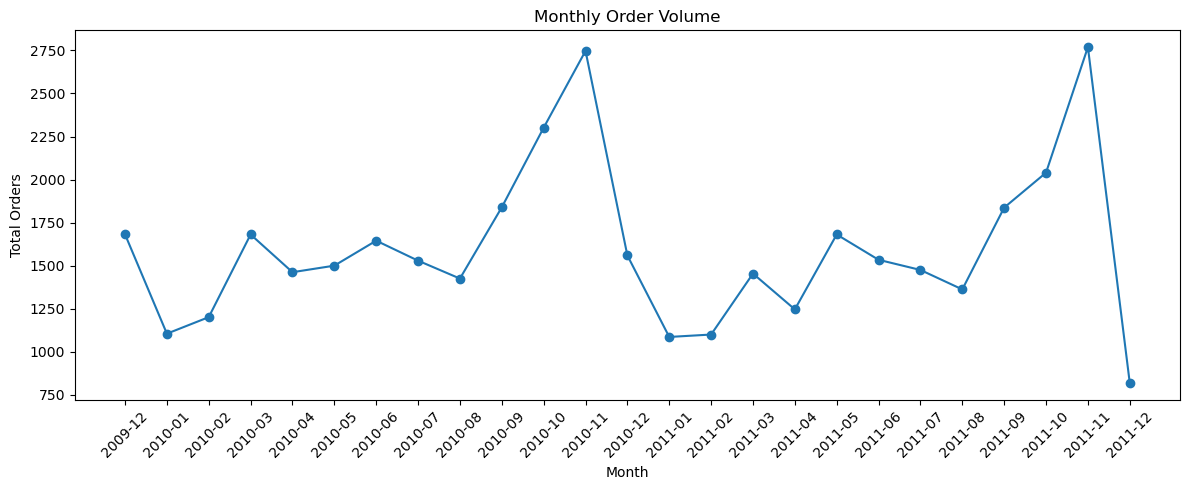

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["month_year"], monthly_orders["total_orders"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

### Monthly Order Volume Insight

Monthly order volume follows a similar pattern to monthly revenue. Orders increase strongly during September, October, and November, with November showing the highest order volume in both 2010 and 2011.

This suggests that revenue growth during peak months is driven by higher customer demand, not only by larger order values.

Business action: The company should prepare inventory, warehouse operations, delivery capacity, and customer support before the September-November peak period.

In [22]:
monthly_aov = (
    df.groupby("month_year")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique")
    )
    .reset_index()
    .sort_values("month_year")
)

monthly_aov["average_order_value"] = (
    monthly_aov["total_revenue"] / monthly_aov["total_orders"]
)

monthly_aov.head()

,month_year,total_revenue,total_orders,average_order_value
0,2009-12,822483.950,1682,488.991647
1,2010-01,651155.112,1105,589.280644
2,2010-02,551504.726,1201,459.204601
3,2010-03,830915.261,1681,494.298192
4,2010-04,678875.252,1462,464.346958


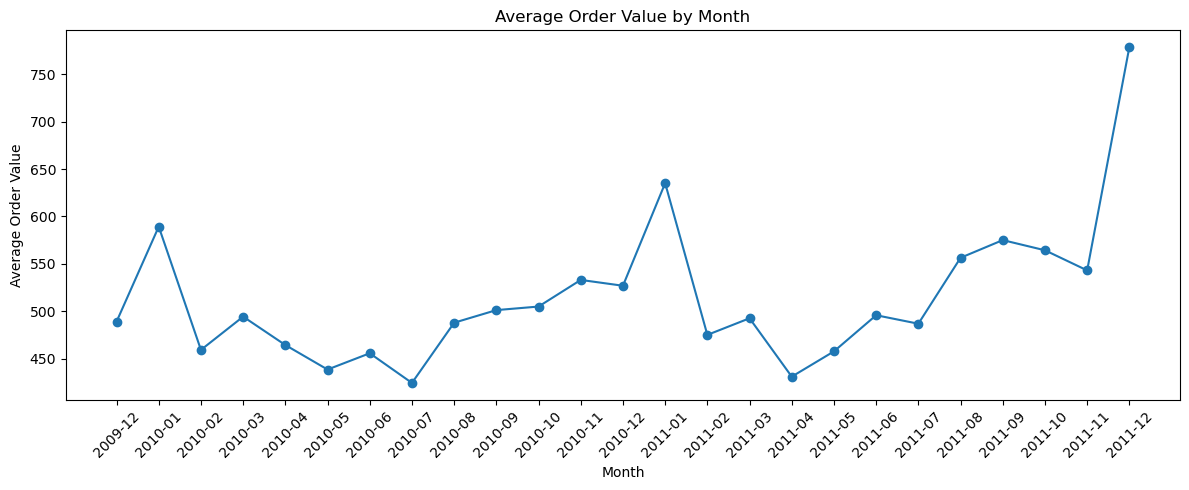

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_aov["month_year"], monthly_aov["average_order_value"], marker="o")
plt.xticks(rotation=45)
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.tight_layout()
plt.show()

### Average Order Value Insight

Average Order Value varies across months, mostly staying between 450 and 575. December 2011 shows the highest AOV, but this should be interpreted carefully because the dataset only includes data until December 9, 2011.

Compared with the monthly revenue and order volume charts, revenue growth during peak months appears to be driven more by increased order volume than by consistently higher order value.

Business action: The company should focus on increasing order volume during peak months while also testing bundles or upsell strategies to improve average order value.

In [25]:
purchase_frequency = (
    df.dropna(subset=["customer_id"])
    .groupby("customer_id")["invoice"]
    .nunique()
    .reset_index()
    .rename(columns={"invoice": "order_count"})
)

one_time = (purchase_frequency["order_count"] == 1).sum()
total_custs = len(purchase_frequency)

print(f"One-time buyers: {one_time:,} ({one_time/total_custs*100:.1f}%)")
print(f"Repeat buyers:   {total_custs - one_time:,} ({(total_custs-one_time)/total_custs*100:.1f}%)")

One-time buyers: 1,623 (27.6%)
Repeat buyers:   4,255 (72.4%)


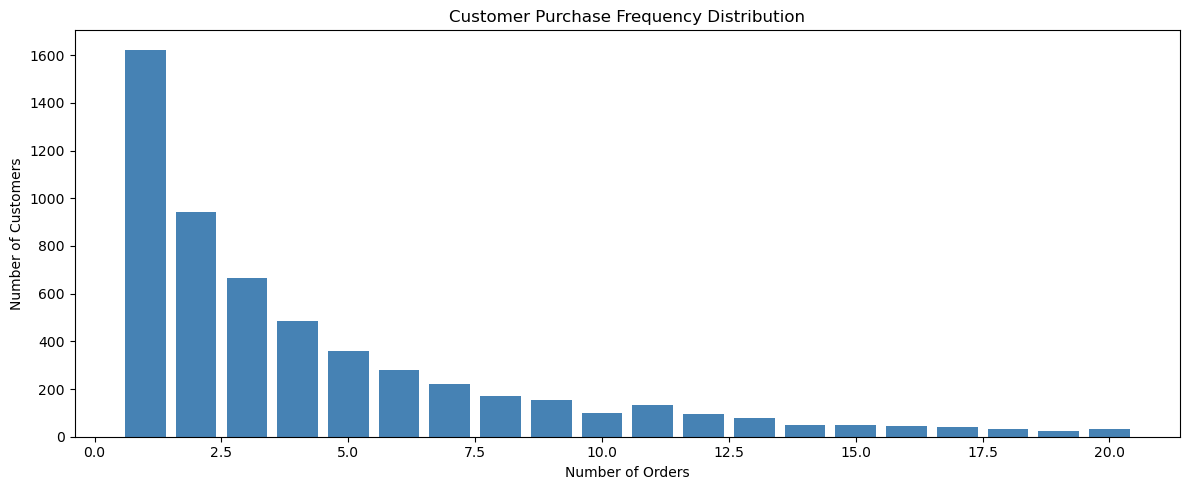

In [26]:
freq_dist = purchase_frequency["order_count"].value_counts().sort_index().head(20)

plt.figure(figsize=(12, 5))
plt.bar(freq_dist.index, freq_dist.values, color="steelblue")
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

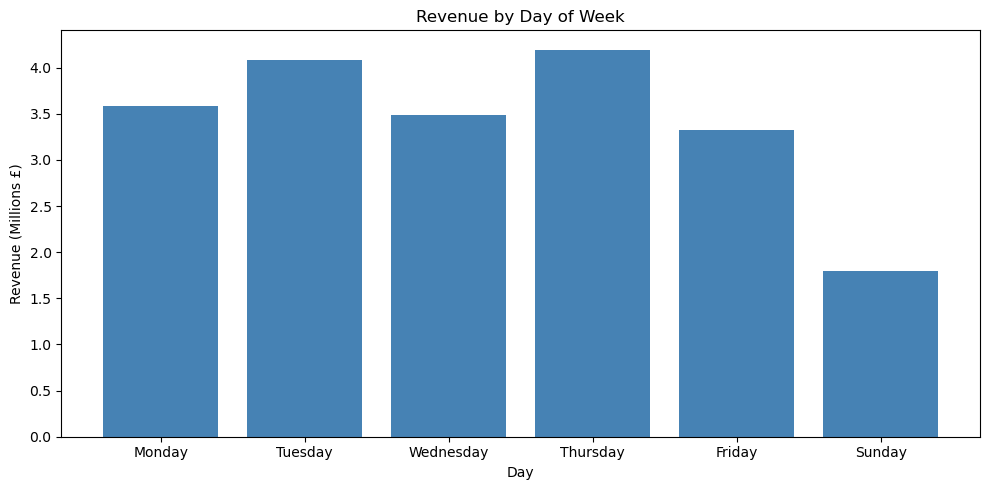

In [27]:
df["day_of_week"] = df["invoicedate"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]

day_revenue = (
    df.groupby("day_of_week")["revenue"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(day_revenue["day_of_week"], day_revenue["revenue"] / 1_000_000, color="steelblue")
plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (Millions £)")
plt.tight_layout()
plt.show()

## EDA Summary

In this phase we analysed revenue trends, country performance, product 
performance, customer value, VIP behaviour, order volume, and average order value 
across ~1M transactions from Dec 2009 to Dec 2011.

### Key Findings

1. **Seasonality** — Revenue and orders peak in September–November. November is 
   the single highest revenue month in both 2010 and 2011.

2. **Geography** — The United Kingdom dominates total revenue. EIRE, Netherlands, 
   Germany, and France are the only meaningful international markets.

3. **Products** — A small number of products (REGENCY CAKESTAND 3 TIER, WHITE 
   HANGING HEART T-LIGHT HOLDER) drive a disproportionate share of revenue.

4. **Customers** — The top 10 customers contribute significantly outsized revenue. 
   Customer 18102 and 14646 alone exceed £500K each.

5. **Repeat vs One-time buyers** — A large proportion of customers purchase only 
   once, indicating a retention problem worth investigating further.

6. **Order volume drives peak revenue** — AOV stays relatively flat across months. 
   Revenue spikes are explained by more orders, not larger orders.
